# Chapter 1 ASIC Hard-Case Comparison Local Review

This notebook is the local-safe review layer for the saved ASIC 24h hard-case comparison package. It uses only the approved aggregate export bundle.

It prefers `cluster-results/chapter1_true_results/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison/` when that mirror is present locally and falls back to `artifacts/chapter1/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison/` otherwise.

This notebook does **not** read `stay_level_comparison_dataset.csv`, and it does **not** rebuild the comparison from restricted inputs.

Embedded outputs, if present, reflect the last time the notebook was executed and may predate the current artifact-source resolution rules.


## 1. Setup / Paths


In [1]:
from __future__ import annotations

import os
import sys
from io import BytesIO
from pathlib import Path

import pandas as pd

if "MPLCONFIGDIR" not in os.environ:
    mplconfigdir = Path("/tmp") / "chapter1_mortality_decomposition_matplotlib"
    mplconfigdir.mkdir(parents=True, exist_ok=True)
    os.environ["MPLCONFIGDIR"] = str(mplconfigdir)

try:
    from IPython import get_ipython
    from IPython.display import Image, Markdown, display
    ipython_shell = get_ipython()
    if ipython_shell is None:
        raise RuntimeError("Plain Python execution: use fallback display helpers.")
    try:
        ipython_shell.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
except Exception:
    ipython_shell = None

    class Markdown(str):
        pass

    class Image:
        def __init__(self, data=None, filename=None):
            self.data = data
            self.filename = filename

        def __repr__(self) -> str:
            return f"Image(filename={self.filename!r})"

    def display(obj: object) -> None:
        print(obj)

import matplotlib
if ipython_shell is None:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def finalize_figure(fig=None) -> None:
    fig = fig or plt.gcf()
    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        if ipython_shell is not None:
            buffer = BytesIO()
            fig.savefig(buffer, format="png", bbox_inches="tight")
            buffer.seek(0)
            display(Image(data=buffer.getvalue()))
            buffer.close()
        plt.close(fig)
        return
    plt.show()


def looks_like_repo_root(path: Path) -> bool:
    return (path / "pyproject.toml").exists() and (path / "src" / "chapter1_mortality_decomposition").exists()


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    search_roots = [start, *start.parents]
    for candidate in search_roots:
        if looks_like_repo_root(candidate):
            return candidate
    for anchor in search_roots:
        try:
            child_dirs = [child for child in anchor.iterdir() if child.is_dir()]
        except Exception:
            continue
        for child in child_dirs:
            if looks_like_repo_root(child):
                return child
    return start


WORKING_DIRECTORY = Path.cwd().resolve()
REPO_ROOT = find_repo_root(WORKING_DIRECTORY)
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from chapter1_mortality_decomposition.notebook_artifact_sources import (
    build_artifact_source_markdown,
    resolve_notebook_artifact_source,
)

COMPARISON_SOURCE = resolve_notebook_artifact_source(
    Path("evaluation") / "asic" / "hard_cases" / "primary_medians" / "logistic_regression" / "asic_hard_case_comparison",
    label="ASIC hard-case comparison aggregate package",
    repo_root=REPO_ROOT,
)
COMPARISON_ROOT = COMPARISON_SOURCE.path
COMPARISON_TABLE_PATH = COMPARISON_ROOT / "comparison_table.csv"
EFFECT_SIZE_PLOT_DATA_PATH = COMPARISON_ROOT / "effect_size_plot_data.csv"
SUMMARY_PATH = COMPARISON_ROOT / "summary.md"
FIGURE_PATH = COMPARISON_ROOT / "effect_size_figure.png"
EARLY_LATE_ROOT = COMPARISON_ROOT / "early_vs_late_death_split"
EARLY_LATE_SUMMARY_PATH = EARLY_LATE_ROOT / "early_vs_late_fatal_timing_summary.csv"
EARLY_LATE_FIGURE_PATH = EARLY_LATE_ROOT / "early_vs_late_low_pred_share.png"
EARLY_LATE_NOTE_PATH = EARLY_LATE_ROOT / "early_vs_late_interpretation_note.md"

REQUIRED_PATHS = [
    COMPARISON_TABLE_PATH,
    EFFECT_SIZE_PLOT_DATA_PATH,
    SUMMARY_PATH,
    FIGURE_PATH,
    EARLY_LATE_SUMMARY_PATH,
    EARLY_LATE_FIGURE_PATH,
    EARLY_LATE_NOTE_PATH,
]

missing_paths = [path for path in REQUIRED_PATHS if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "The approved hard-case comparison aggregate bundle is incomplete. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

comparison_table = pd.read_csv(COMPARISON_TABLE_PATH)
effect_size_plot_data = pd.read_csv(EFFECT_SIZE_PLOT_DATA_PATH)
early_vs_late_summary = pd.read_csv(EARLY_LATE_SUMMARY_PATH)
summary_text = SUMMARY_PATH.read_text(encoding="utf-8")
early_vs_late_note = EARLY_LATE_NOTE_PATH.read_text(encoding="utf-8")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def relative_to_repo(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return str(path.resolve())


def render_image(path: Path, title: str) -> None:
    if not path.exists():
        display(Markdown(f"_Missing figure: `{relative_to_repo(path)}`_"))
        return
    image = plt.imread(path)
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(title)
    fig.tight_layout()
    finalize_figure(fig)


display(Markdown(f"Working directory: `{WORKING_DIRECTORY}`"))
display(Markdown(f"Repository root: `{REPO_ROOT}`"))
display(Markdown(build_artifact_source_markdown([COMPARISON_SOURCE], display_root=REPO_ROOT)))
display(Markdown("This notebook consumes only the approved aggregate export bundle for local review."))

artifact_paths = pd.DataFrame(
    [
        {"artifact_name": "comparison table", "path": relative_to_repo(COMPARISON_TABLE_PATH), "exists": COMPARISON_TABLE_PATH.exists()},
        {"artifact_name": "effect-size plot data", "path": relative_to_repo(EFFECT_SIZE_PLOT_DATA_PATH), "exists": EFFECT_SIZE_PLOT_DATA_PATH.exists()},
        {"artifact_name": "summary note", "path": relative_to_repo(SUMMARY_PATH), "exists": SUMMARY_PATH.exists()},
        {"artifact_name": "effect-size figure", "path": relative_to_repo(FIGURE_PATH), "exists": FIGURE_PATH.exists()},
        {"artifact_name": "early-vs-late timing summary", "path": relative_to_repo(EARLY_LATE_SUMMARY_PATH), "exists": EARLY_LATE_SUMMARY_PATH.exists()},
        {"artifact_name": "early-vs-late timing figure", "path": relative_to_repo(EARLY_LATE_FIGURE_PATH), "exists": EARLY_LATE_FIGURE_PATH.exists()},
        {"artifact_name": "early-vs-late interpretation note", "path": relative_to_repo(EARLY_LATE_NOTE_PATH), "exists": EARLY_LATE_NOTE_PATH.exists()},
    ]
)
display(Markdown("### Aggregate Artifact Paths"))
display(artifact_paths)


Working directory: `/Users/joanameyer/repository/1-mortality-decomposition/notebooks`

Repository root: `/Users/joanameyer/repository/1-mortality-decomposition`

## Artifact Source Mode

All notebook inputs currently resolve to `cluster export` artifacts. These are the authoritative local mirror of approved HPC outputs.

| input | tier | path |
| --- | --- | --- |
| ASIC hard-case comparison aggregate package | `cluster export` | `cluster-results/chapter1_true_results/evaluation/asic/hard_cases/primary_medians/logistic_regression/asic_hard_case_comparison` |

This notebook consumes only the approved aggregate export bundle for local review.

### Aggregate Artifact Paths

,artifact_name,path,exists
0,comparison table,cluster-results/chapter1_true_results/evaluati...,True
1,effect-size plot data,cluster-results/chapter1_true_results/evaluati...,True
2,summary note,cluster-results/chapter1_true_results/evaluati...,True
3,effect-size figure,cluster-results/chapter1_true_results/evaluati...,True
4,early-vs-late timing summary,cluster-results/chapter1_true_results/evaluati...,True
5,early-vs-late timing figure,cluster-results/chapter1_true_results/evaluati...,True
6,early-vs-late interpretation note,cluster-results/chapter1_true_results/evaluati...,True


## 2. Summary Note


In [2]:
display(Markdown(summary_text))


# ASIC 24h Fatal-Stay Hard-Case Comparison

## Cohort
- Fatal 24h stay-level comparison dataset: `1682` stays.
- Low-predicted fatal stays: `346`. Other fatal stays: `1336`.
- Hard-case anchor: `asic_logistic_last_eligible_nonfatal_q75_v1` from the saved stay-level hard-case artifact.

## Main Differences
- Low-predicted fatal stays were modestly more common among `asic_UK04` fatal stays (37/346, 11%) than among other fatal stays (71/1336, 5%).
- Low-predicted fatal stays were modestly enriched in `neurologic` disease-group assignments (7/346, 2% vs 0%).
- Among the frozen timing and physiologic proxies, MAP was higher, PF ratio was modestly higher, and PEEP was modestly lower among low-predicted fatal stays.

## Caveat
- This is a bounded descriptive comparison on a small 24h fatal-only slice (`346` vs `1336` stays), so the outputs should be read as chapter-oriented structure rather than stable subgroup estimates.


## 3. Main Comparison Table


In [3]:
display(Markdown("### Main Table"))
display(comparison_table)

display(Markdown("### Strongest absolute effect sizes"))
display(effect_size_plot_data.loc[:, [
    "figure_label",
    "effect_size_type",
    "effect_size_basis",
    "standardized_difference",
    "absolute_standardized_difference",
]].head(5))


### Main Table

,variable,variable_label,low_predicted_fatal_stays,other_fatal_stays,effect_size_type,effect_size_basis,standardized_difference,absolute_standardized_difference
0,age_group,Age group,<70: 162 (47%); 70-79: 103 (30%); 80-130: 81 (...,<70: 716 (54%); 70-79: 378 (28%); 80-130: 242 ...,max absolute level-specific standardized diffe...,<70,-0.136,0.136
1,sex,Sex,F: 117 (34%); M: 229 (66%),F: 512 (38%); M: 824 (62%),max absolute level-specific standardized diffe...,M,0.094,0.094
2,disease_group,Disease group,surgical / postoperative / trauma-related: 191...,surgical / postoperative / trauma-related: 764...,max absolute level-specific standardized diffe...,neurologic,0.192,0.192
3,hospital_id,Hospital,asic_UK02: 27 (8%); asic_UK04: 37 (11%); asic_...,asic_UK02: 185 (14%); asic_UK04: 71 (5%); asic...,max absolute level-specific standardized diffe...,asic_UK04,0.199,0.199
4,prediction_time_h,Prediction time from ICU admission (h),"176 [96, 310] (n=346)","232 [96, 456] (n=1336)",continuous pooled-SD standardized mean difference,available values,-0.179,0.179
5,pf_ratio_last,PF ratio,"277.7 [204.7, 344.4] (n=224)","172.3 [111.3, 257.5] (n=1009)",continuous pooled-SD standardized mean difference,available values,0.696,0.696
6,map_last,MAP,"81.0 [68.3, 92.2] (n=336)","58.1 [38.4, 71.0] (n=1306)",continuous pooled-SD standardized mean difference,available values,0.952,0.952
7,creatinine_last,Creatinine,"78.7 [55.7, 123.8] (n=340)","106.1 [69.8, 161.0] (n=1310)",continuous pooled-SD standardized mean difference,available values,-0.166,0.166
8,peep_last,PEEP,"9.3 [6.5, 10.2] (n=263)","10.1 [8.0, 12.2] (n=1186)",continuous pooled-SD standardized mean difference,available values,-0.531,0.531


### Strongest absolute effect sizes

,figure_label,effect_size_type,effect_size_basis,standardized_difference,absolute_standardized_difference
0,MAP,continuous pooled-SD standardized mean difference,available values,0.952,0.952
1,PF ratio,continuous pooled-SD standardized mean difference,available values,0.696,0.696
2,PEEP,continuous pooled-SD standardized mean difference,available values,-0.531,0.531
3,Hospital (asic_UK04),max absolute level-specific standardized diffe...,asic_UK04,0.199,0.199
4,Disease group (neurologic),max absolute level-specific standardized diffe...,neurologic,0.192,0.192


## 4. Effect-Size Figure


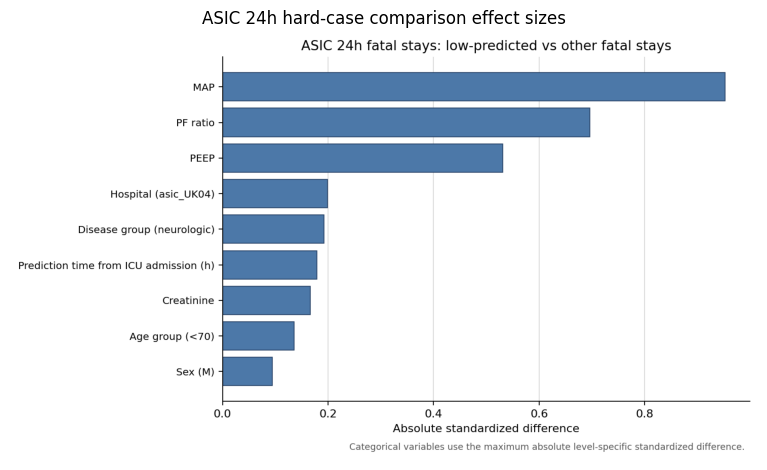

In [4]:
render_image(FIGURE_PATH, "ASIC 24h hard-case comparison effect sizes")


## 5. Early-vs-Late Fatal Timing Appendix


### Early-vs-Late Timing Summary

,section,variable,variable_label,early_icu_death,late_icu_death,comparison_statistic,comparison_value,comparison_basis
0,core_timing_summary,fatal_stays,Fatal stays,122 (7.3% of fatal stays),1560 (92.7% of fatal stays),share of all fatal stays,NaN,within fatal stays
1,core_timing_summary,low_predicted_fatal,Low-predicted fatal stays,25 (20%),321 (21%),absolute difference in low-predicted fatal sha...,0.085,late minus early = +0.1 pp
2,core_timing_summary,other_fatal,Other fatal stays,97 (80%),1239 (79%),row percentages within timing group,NaN,complement of low-predicted fatal share
3,core_timing_summary,comparison_status,Compact descriptive comparison,performed,performed,sparse-stop rule,NaN,require >=10 fatal stays per timing group and ...
4,compact_descriptive_comparison,age_group,Age group,<70: 67 (55%); 70-79: 27 (22%); 80-130: 28 (23%),<70: 811 (52%); 70-79: 454 (29%); 80-130: 295 ...,max absolute level-specific standardized diffe...,0.160,70-79
5,compact_descriptive_comparison,disease_group,Disease group,surgical / postoperative / trauma-related: 45 ...,surgical / postoperative / trauma-related: 910...,max absolute level-specific standardized diffe...,0.440,surgical / postoperative / trauma-related
6,compact_descriptive_comparison,hospital_id,Hospital,asic_UK02: 26 (21%); asic_UK04: 15 (12%); asic...,asic_UK02: 186 (12%); asic_UK04: 93 (6%); asic...,max absolute level-specific standardized diffe...,0.254,asic_UK02
7,compact_descriptive_comparison,prediction_time_h,Prediction time from ICU admission (h),"32 [32, 40] (n=122)","240 [120, 448] (n=1560)",continuous pooled-SD standardized mean difference,1.172,available values
8,compact_descriptive_comparison,icu_end_time_proxy_hours,ICU death/end proxy time from admission (h),"37.2 [32.5, 42.2] (n=122)","241.2 [120.5, 454.3] (n=1560)",continuous pooled-SD standardized mean difference,1.171,available values
9,compact_descriptive_comparison,creatinine_last,Creatinine,"108.4 [72.9, 159.9] (n=122)","98.1 [64.5, 154.7] (n=1528)",continuous pooled-SD standardized mean difference,0.067,available values


### Early-vs-Late Interpretation Note

# Early vs Late Fatal Timing Note

- This appendix-only sensitivity reuses the frozen ASIC fatal-stay hard-case artifact anchored to `asic_logistic_last_eligible_nonfatal_q75_v1`.
- Fatal stays are split pragmatically at 48 hours from ICU admission using `icu_end_time_proxy_hours` from the existing Chapter 1 proxy-label workflow: `early ICU death (<=48h)` vs `late ICU death (>48h)`.
- Low-predicted fatal stays were `25/122` (20.5%) among early ICU deaths and `321/1560` (20.6%) among late ICU deaths; absolute share difference = `0.1` percentage points.
- Low-predicted fatal cases were not more concentrated in early ICU deaths; the larger share was among later ICU deaths.
- Early-vs-late timing does not materially alter the existing ASIC hard-case interpretation.
- Chapter 1 value: this looks essentially negligible and can be dropped as non-consequential.
- This is descriptive only. The late-death group is not a baseline subgroup, so the split should not be given immortal-time-style, causal, or subtype interpretation.
- The 48h split is a pragmatic binary sensitivity choice for interpretability, not evidence of biological death subtypes.
- Admission type was not available in the frozen comparison dataset, so the compact comparison reuses only existing age-group, disease-group, site, timing, creatinine, and PEEP fields from the established hard-case workflow.


### Early-vs-Late Figure

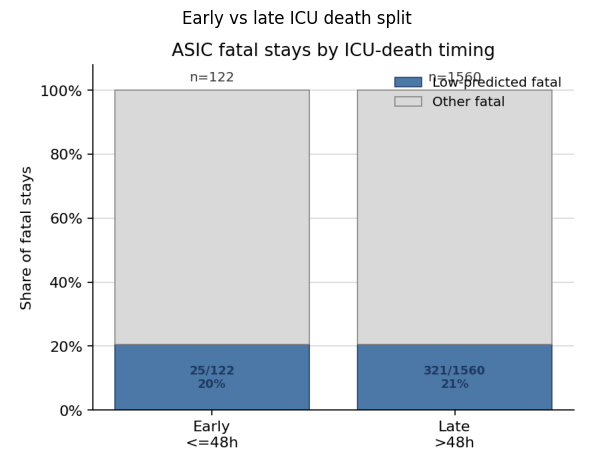

In [5]:
display(Markdown("### Early-vs-Late Timing Summary"))
display(early_vs_late_summary)

display(Markdown("### Early-vs-Late Interpretation Note"))
display(Markdown(early_vs_late_note))

display(Markdown("### Early-vs-Late Figure"))
render_image(EARLY_LATE_FIGURE_PATH, "Early vs late ICU death split")
